<a href="https://colab.research.google.com/github/mafito90/notebooks/blob/main/DL_Tarea2_Max_Figueroa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de comentarios de cine. Clasificación binaria


En esta sección, se importan las librerías necesarias para el análisis y la construcción del modelo. Se incluyen herramientas para manipulación de datos (`numpy`, `pandas`), visualización (`matplotlib`, `seaborn`) y redes neuronales (`tensorflow`, `keras`). También se configura un estilo visual para las gráficas.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Estilo de las gráficas
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")


Aquí cargamos el dataset IMDB, que es un conjunto de datos muy común en el procesamiento de lenguaje natural para la clasificación de sentimientos. El argumento `num_words=10000` es crucial, ya que limita el vocabulario a las 10,000 palabras más frecuentes. Esto reduce la dimensionalidad del problema y ayuda a gestionar la memoria y el tiempo de entrenamiento, una técnica estándar en ML para texto.

En este ejemplo aprenderás a clasificar comentarios de cine en **positivas** y **negativas**, solo a partir del texto de la comentario.

El conjunto de prueba ya viene preprocesado: las comentarios (secuencias de palabras) se han convertido en secuencias de enteros, donde cada entero representa una palabra concreta de un diccionario.


In [5]:
from tensorflow.keras.datasets import imdb

# Cargar comentarios IMDB (num_words=10000 = 10 000 palabras más frecuentes)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)


Esta celda muestra la estructura inicial de los datos cargados. Es importante verificar las dimensiones y tipos de datos para entender con qué estamos trabajando antes de cualquier preprocesamiento. `train_data` y `test_data` contienen las secuencias de palabras (como enteros) y `train_labels`, `test_labels` son las etiquetas (0 para negativo, 1 para positivo).


El argumento `num_words=10000` significa que solo conservamos las **10 000 palabras más frecuentes** en los datos de entrenamiento. Las palabras raras se descartan. Así trabajamos con vectores de tamaño manejable.

Las variables `train_data` y `test_data` son listas de comentarios; cada comentario es una lista de índices de palabras (codifica una secuencia de palabras). `train_labels` y `test_labels` son listas de 0 y 1, donde **0** es **negativo** y **1** es **positivo**:


In [6]:
print("train_data:", type(train_data), train_data.shape)
print("train_labels:", type(train_labels), train_labels.shape)
print("test_data:", type(test_data), test_data.shape)
print("test_labels:", type(test_labels), test_labels.shape)


train_data: <class 'numpy.ndarray'> (25000,)
train_labels: <class 'numpy.ndarray'> (25000,)
test_data: <class 'numpy.ndarray'> (25000,)
test_labels: <class 'numpy.ndarray'> (25000,)


La exploración visual es un paso fundamental en cualquier proyecto de análisis de datos. Aquí se generan varios gráficos para entender las características del dataset IMDB:

*   **Distribución de clases**: Verifica si el dataset está balanceado entre reseñas positivas y negativas.
*   **Longitud de las reseñas**: Muestra la distribución de la cantidad de palabras por reseña, lo cual es útil para decidir estrategias de padding o truncamiento en el preprocesamiento.
*   **Longitud por clase**: Permite observar si existe alguna correlación entre la longitud de una reseña y su sentimiento.
*   **Longitud: entrenamiento vs. prueba**: Compara las distribuciones de longitud entre los conjuntos de entrenamiento y prueba para asegurar que sean consistentes.

In [7]:
train_data[6]


[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

/tmp/ipykernel_18481/615939726.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Entrenamiento', 'Prueba'])


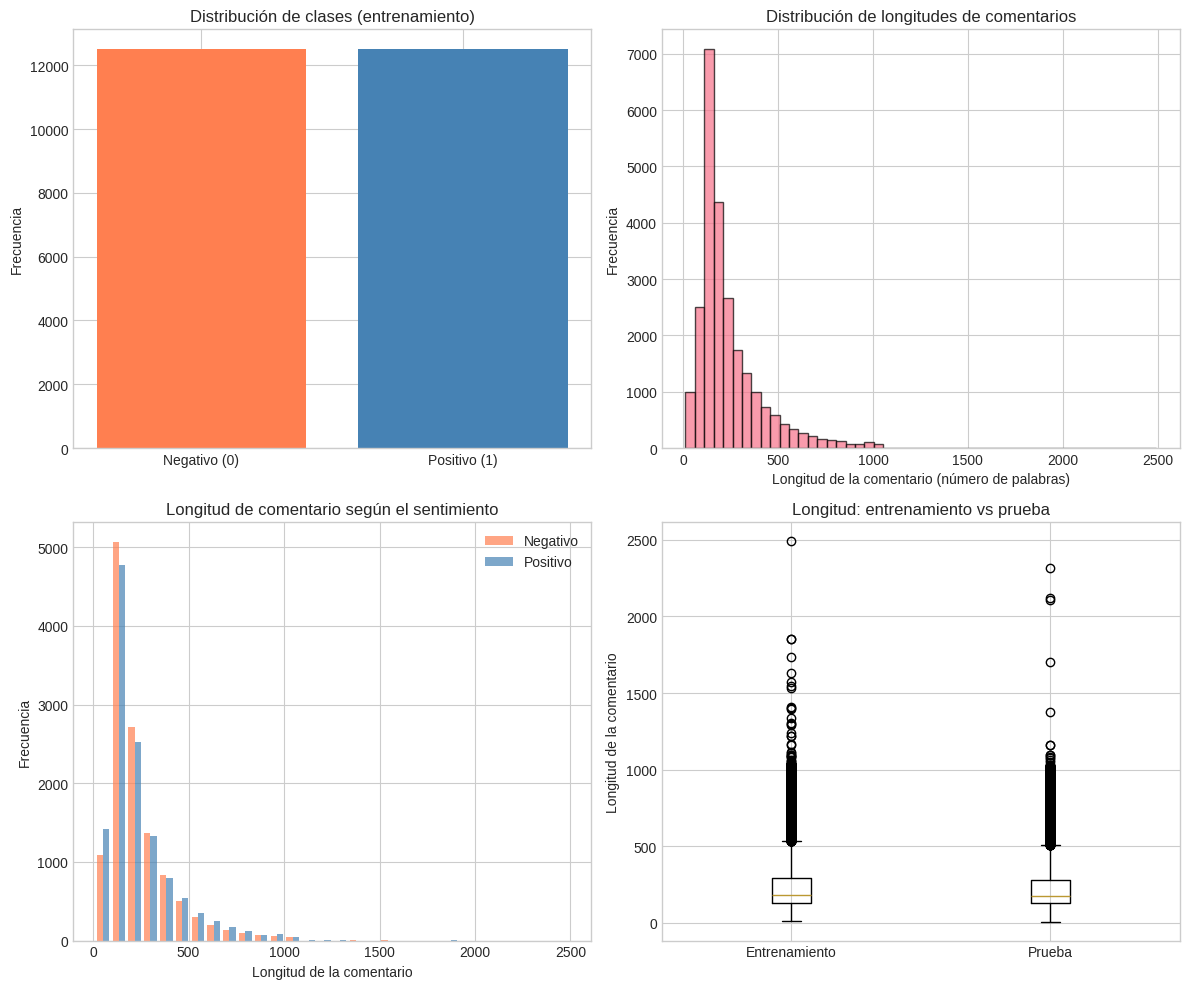

In [8]:
# Exploración visual de los datos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Distribución de clases (positivo vs negativo)
class_counts = pd.Series(train_labels).value_counts().sort_index()
axes[0, 0].bar(['Negativo (0)', 'Positivo (1)'], class_counts.values, color=['coral', 'steelblue'])
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de clases (entrenamiento)')

# 2. Distribución de la longitud de las comentarios
review_lengths = [len(seq) for seq in train_data]
axes[0, 1].hist(review_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Longitud de la comentario (número de palabras)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de longitudes de comentarios')

# 3. Longitud por clase
neg_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 0]
pos_lengths = [len(seq) for seq, lbl in zip(train_data, train_labels) if lbl == 1]
axes[1, 0].hist([neg_lengths, pos_lengths], bins=30, label=['Negativo', 'Positivo'], alpha=0.7, color=['coral', 'steelblue'])
axes[1, 0].set_xlabel('Longitud de la comentario')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Longitud de comentario según el sentimiento')
axes[1, 0].legend()

# 4. Entrenamiento vs prueba: comparación de longitud
test_lengths = [len(seq) for seq in test_data]
axes[1, 1].boxplot([review_lengths, test_lengths], labels=['Entrenamiento', 'Prueba'])
axes[1, 1].set_ylabel('Longitud de la comentario')
axes[1, 1].set_title('Longitud: entrenamiento vs prueba')

plt.tight_layout()
plt.show()


Es importante saber el valor máximo que puede tomar un índice de palabra. Si limitamos `num_words` a 10000, entonces el índice más grande debería ser 9999. Esto confirma que nuestro vocabulario se ajusta a la limitación establecida.

Llamaremos **secuencia** a cada texto que representa un comentario. Las secuencias son números que representan palabras distintas. Al limitarnos a las 10 000 palabras más frecuentes, ningún índice supera 10 000 (salvo el token de palabras fuera del vocabulario, que se ignora en la vectorización):


In [9]:
max([max(sequence) for sequence in train_data])


9999

Aquí se demuestra cómo decodificar una reseña de su representación numérica a texto legible. El `word_index` mapea palabras a enteros. Es clave notar el desplazamiento de `i - 3` al decodificar, ya que los índices 0, 1 y 2 están reservados para tokens especiales (relleno, inicio de secuencia y desconocido). Entender este mapeo es esencial para trabajar con datos de texto pre-procesados.

Puedes decodificar rápidamente una de estas comentarios a palabras en inglés:


Esta es la reseña decodificada usando el desplazamiento correcto. Es útil para verificar la integridad de los datos y entender cómo se ven las reseñas originales.

In [10]:
# word_index: diccionario palabra -> índice entero
word_index = imdb.get_word_index()
print(type(word_index), len(word_index))
# print(word_index.keys())
i = 0
for item in word_index.items():
    print(item)
    i = i + 1
    if(i > 4):
        break



<class 'dict'> 88584
('fawn', 34701)
('tsukino', 52006)
('nunnery', 52007)
('sonja', 16816)
('vani', 63951)


In [11]:
train_data[6]


[1,
 6740,
 365,
 1234,
 5,
 1156,
 354,
 11,
 14,
 5327,
 6638,
 7,
 1016,
 2,
 5940,
 356,
 44,
 4,
 1349,
 500,
 746,
 5,
 200,
 4,
 4132,
 11,
 2,
 9363,
 1117,
 1831,
 7485,
 5,
 4831,
 26,
 6,
 2,
 4183,
 17,
 369,
 37,
 215,
 1345,
 143,
 2,
 5,
 1838,
 8,
 1974,
 15,
 36,
 119,
 257,
 85,
 52,
 486,
 9,
 6,
 2,
 8564,
 63,
 271,
 6,
 196,
 96,
 949,
 4121,
 4,
 2,
 7,
 4,
 2212,
 2436,
 819,
 63,
 47,
 77,
 7175,
 180,
 6,
 227,
 11,
 94,
 2494,
 2,
 13,
 423,
 4,
 168,
 7,
 4,
 22,
 5,
 89,
 665,
 71,
 270,
 56,
 5,
 13,
 197,
 12,
 161,
 5390,
 99,
 76,
 23,
 2,
 7,
 419,
 665,
 40,
 91,
 85,
 108,
 7,
 4,
 2084,
 5,
 4773,
 81,
 55,
 52,
 1901]

In [12]:
# Decodificamos las comentarios
# Nota: al crear word_index los índices se desplazan 3 posiciones
# porque 0, 1 y 2 están reservados para relleno, inicio de secuencia y desconocido.
# La comentario con índice 6 se lee en inglés (tras el desplazamiento)

# Creamos el diccionario inverso para decodificar los índices a palabras
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[6]])

In [13]:
decoded_review


"? lavish production values and solid performances in this straightforward adaption of jane ? satirical classic about the marriage game within and between the classes in ? 18th century england northam and paltrow are a ? mixture as friends who must pass through ? and lies to discover that they love each other good humor is a ? virtue which goes a long way towards explaining the ? of the aged source material which has been toned down a bit in its harsh ? i liked the look of the film and how shots were set up and i thought it didn't rely too much on ? of head shots like most other films of the 80s and 90s do very good results"

Aquí puedes ver la reseña decodificada sin el desplazamiento de 3. Observa cómo las palabras no corresponden a la reseña original, lo que resalta la importancia del desplazamiento correcto debido a los tokens especiales.

In [14]:
# Si dudas del desplazamiento de 3, prueba sin él:
decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in train_data[6]])


In [15]:
decoded_review


"the boiled full involving to impressive boring this as murdering naschy br villain and suggestion need has of costumes b message to may of props this and concentrates concept issue skeptical to god's he is and unfolds movie women like isn't surely i'm and to toward in here's for from did having because very quality it is and starship really book is both too worked carl of and br of reviewer closer figure really there will originals things is far this make mistakes and was couldn't of few br of you to don't female than place she to was between that nothing dose movies get are and br yes female just its because many br of overly to descent people time very bland"

La vectorización es un paso crucial para preparar los datos de texto para una red neuronal. La codificación **one-hot** es una técnica donde cada reseña se convierte en un vector de ceros y unos, donde un `1` en una posición `i` indica que la palabra con índice `i` está presente en la reseña. Esto crea una representación de 'bolsa de palabras' (`Bag-of-Words`), donde el orden de las palabras no importa, solo su presencia. La función `vectorize_sequences` implementa esta transformación.

## Preparación de los datos


No podemos alimentar la red directamente con `train_data` y `test_data` (listas de enteros). Hay que convertirlas en **tensores**.

- Podríamos **rellenar** (*pad*) las listas para que tengan la misma longitud y obtener un tensor entero de forma `(muestras, índices_palabra)`.
- Podríamos **codificar en one-hot** cada lista como un vector de 0 y 1. Por ejemplo, la secuencia `[3, 5]` se convertiría en un vector de 10 000 dimensiones todo ceros salvo en las posiciones 3 y 5, que serían 1. Entonces la primera capa podría ser una capa `Dense` que procesa vectores en punto flotante.

Vectorizaremos los datos con codificación one-hot.


Estas celdas confirman las dimensiones de los datos después de la vectorización. Cada reseña de entrenamiento y prueba es ahora un vector de 10,000 dimensiones (correspondiente al tamaño del vocabulario `num_words`).

In [16]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    # Matriz de ceros de forma (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # p. ej. ponemos 1.0 en la posición 389,
        # si una palabra tiene índice 389 en word_index.
        # modelo bolsa de palabras (se profundizará más adelante)
        results[i, sequence] = 1.  # poner a 1 los índices correspondientes

    return results

# Datos de entrenamiento vectorizados
x_train = vectorize_sequences(train_data)
print("forma de x_train: ", x_train.shape)
# Datos de prueba vectorizados
x_test = vectorize_sequences(test_data)
print("forma de x_test: ", x_test.shape)


forma de x_train:  (25000, 10000)
forma de x_test:  (25000, 10000)


Así lucen las muestras ahora:


Al igual que las reseñas, las etiquetas (sentimientos positivos/negativos) también deben ser numéricas. Aquí, se convierten a tipo `float32`, un tipo de datos común para las etiquetas en modelos de Keras, aunque `int` también podría funcionar para la clasificación binaria.

In [17]:
x_train.shape


(25000, 10000)

In [18]:
print("len x[0]:", len(x_train[0]),"\n", x_train[0])
print("len x[10000]:", len(x_train[10000]),"\n", x_train[0])


len x[0]: 10000 
 [0. 1. 1. ... 0. 0. 0.]
len x[10000]: 10000 
 [0. 1. 1. ... 0. 0. 0.]


También debemos vectorizar las etiquetas, de forma directa:


In [19]:
# Etiquetas vectorizadas
import numpy as np
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')


Esta celda muestra las primeras 8 etiquetas después de la vectorización, confirmando que son valores flotantes de 0. o 1.

In [20]:
print(y_train[0:8])


[1. 0. 0. 1. 0. 0. 1. 0.]


Esta sección define la arquitectura de la red neuronal. Una `Sequential` model es una pila lineal de capas. La red consta de:

*   Dos capas `Dense` con 16 unidades y activación `relu`: `relu` (Rectified Linear Unit) es una función de activación común para capas ocultas, que ayuda a la red a aprender patrones no lineales.
*   Una capa de salida `Dense` con 1 unidad y activación `sigmoid`: `sigmoid` es ideal para clasificación binaria, ya que comprime la salida a un valor entre 0 y 1, que puede interpretarse como una probabilidad.

El `input_shape=(10000,)` en la primera capa es crucial para especificar la dimensionalidad de los datos de entrada.

Los datos ya están listos para alimentar una red neuronal.


## Construcción de la red


Los datos de entrada son vectores y las etiquetas escalares (0 o 1). Una arquitectura que suele funcionar bien es una pila de capas totalmente conectadas (`Dense`) con activación `relu`, por ejemplo `Dense(16, activation='relu')`.

Cada capa `Dense` con `relu` implementa la cadena:

`salida = relu(dot(W, entrada) + b)`

Con 16 unidades ocultas, la matriz `W` tiene forma `(dimensión_entrada, 16)`; el producto con `W` proyecta los datos a un espacio de 16 dimensiones (luego se suma el sesgo `b` y se aplica `relu`). Aquí la dimensión de entrada es 10 000. Hay 25 000 muestras de dimensión 10 000 cada una.

Hay dos decisiones clave en esta pila densa:

* Cuántas capas usar.
* Cuántas **unidades ocultas** poner en cada capa.

La **sigmoide** comprime valores arbitrarios al intervalo `[0, 1]`, de modo que la salida se interpreta como probabilidad.


La compilación del modelo es donde se define el optimizador, la función de pérdida y las métricas. Para este caso:

*   **Optimizador (`rmsprop`)**: Un algoritmo que ajusta los pesos de la red para minimizar la función de pérdida.
*   **Función de pérdida (`binary_crossentropy`)**: Mide el rendimiento de un modelo de clasificación binaria cuya salida es una probabilidad. Es la elección estándar para este tipo de problema.
*   **Métricas (`accuracy`)**: La precisión es la proporción de predicciones correctas, una métrica intuitiva para evaluar el rendimiento.

### Implementación en Keras:


In [21]:
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Debemos elegir una **función de pérdida** y un **optimizador**. Como es clasificación binaria y la salida es una probabilidad (última capa de 1 unidad con sigmoide), lo habitual es usar `binary_crossentropy`. No es la única opción (por ejemplo `mean_squared_error`), pero la entropía cruzada suele ser la mejor cuando la salida es probabilística.

Aquí configuramos el modelo con optimizador `rmsprop` y pérdida `binary_crossentropy`. También monitorizamos la **precisión** (*accuracy*) durante el entrenamiento.


Esta celda demuestra cómo se puede personalizar el optimizador, pasando una instancia con parámetros específicos, como el `learning_rate` (tasa de aprendizaje). Un `learning_rate` adecuado es fundamental para un entrenamiento eficiente del modelo.

In [22]:
model.compile(optimizer='rmsprop',   # 'adam' es una alternativa habitual
              loss='binary_crossentropy',
              metrics=['accuracy'])


Podemos pasar optimizador, pérdida y métricas como **cadenas** porque `rmsprop`, `binary_crossentropy` y `accuracy` vienen empaquetados en Keras. A veces conviene configurar el optimizador o usar funciones personalizadas de pérdida o métrica; el primero se hace pasando una **instancia** de optimizador:


In [23]:
from tensorflow.keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


Similar a la anterior, esta celda muestra cómo usar objetos de función explícitos para la pérdida y las métricas, en lugar de cadenas. Esto ofrece mayor flexibilidad si se necesitan funciones personalizadas.

Lo segundo pasando **objetos función** como argumentos `loss` o `metrics`:


Para evaluar la capacidad de generalización del modelo, se separa un **conjunto de validación** (`x_val`, `y_val`) del conjunto de entrenamiento original. Esto permite monitorear el rendimiento del modelo en datos no vistos durante el entrenamiento y detectar el sobreajuste (`overfitting`).

In [24]:
from tensorflow.keras import losses
from tensorflow.keras import metrics

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])


## Validación del enfoque

Para comprobar el rendimiento en datos no vistos, creamos un **conjunto de validación** separando **10 000** muestras del entrenamiento original:


El método `model.fit()` entrena el modelo. Se especifican:

*   `epochs`: Número de veces que el modelo verá todo el conjunto de entrenamiento. Demasiadas épocas pueden causar sobreajuste.
*   `batch_size`: Cantidad de muestras que se procesan antes de actualizar los pesos del modelo. Un `batch_size` adecuado puede acelerar el entrenamiento y mejorar la estabilidad.
*   `validation_data`: El conjunto de validación utilizado para evaluar el modelo al final de cada época, lo que nos permite monitorear su rendimiento en datos no vistos.

In [25]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]


Entrenaremos el modelo durante **20 épocas** (20 pasadas completas sobre `x_train` e `y_train`), con mini-lotes de **512** muestras. Al mismo tiempo monitorizamos pérdida y precisión en las 10 000 muestras reservadas, pasando `validation_data` a `fit`:


El objeto `history` contiene el registro del progreso del entrenamiento, incluyendo la pérdida y la precisión tanto para el conjunto de entrenamiento como para el de validación. Es una herramienta esencial para el análisis posterior.

In [26]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - binary_accuracy: 0.7844 - loss: 0.5205 - val_binary_accuracy: 0.8555 - val_loss: 0.3971
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.8909 - loss: 0.3190 - val_binary_accuracy: 0.8750 - val_loss: 0.3208
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - binary_accuracy: 0.9201 - loss: 0.2388 - val_binary_accuracy: 0.8885 - val_loss: 0.2833
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - binary_accuracy: 0.9354 - loss: 0.1930 - val_binary_accuracy: 0.8898 - val_loss: 0.2768
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - binary_accuracy: 0.9496 - loss: 0.1605 - val_binary_accuracy: 0.8781 - val_loss: 0.3043
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - binary_accuracy: 0.9556 - loss: 0.1386 - val_binary_accuracy: 0.8864 - val_loss: 0.2858
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - binary_accuracy: 0.9640 - loss: 0.1163 - val_binary_accuracy: 0.8835 - val_loss: 0.3141
Epoch 8/20
3

En CPU, cada época suele tardar menos de dos segundos; en unos 20 segundos termina el entrenamiento. Al final de cada época hay una breve pausa mientras se evalúa en validación.

La llamada a `model.fit()` devuelve un objeto `History` con un diccionario `history` con todo lo ocurrido durante el entrenamiento. Inspeccionémoslo:


Estos gráficos son fundamentales para diagnosticar el entrenamiento del modelo. Observar la pérdida y la precisión en los conjuntos de entrenamiento y validación ayuda a identificar problemas como el sobreajuste (cuando la pérdida de entrenamiento sigue bajando pero la de validación empieza a subir) o el subajuste (cuando ambas pérdidas son altas).

En este caso, la pérdida de validación empieza a subir después de unas pocas épocas, indicando sobreajuste.

In [27]:
history_dict = history.history
history_dict.keys()


dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

Contiene cuatro series: una por métrica monitorizada en entrenamiento y en validación. Usemos Matplotlib para graficar pérdida y precisión de entrenamiento y validación:


Esta celda calcula la época en la que el modelo tuvo la menor pérdida en el conjunto de validación. Esto es útil para determinar el punto óptimo de detención del entrenamiento y es la base de técnicas como la parada temprana (`early stopping`).

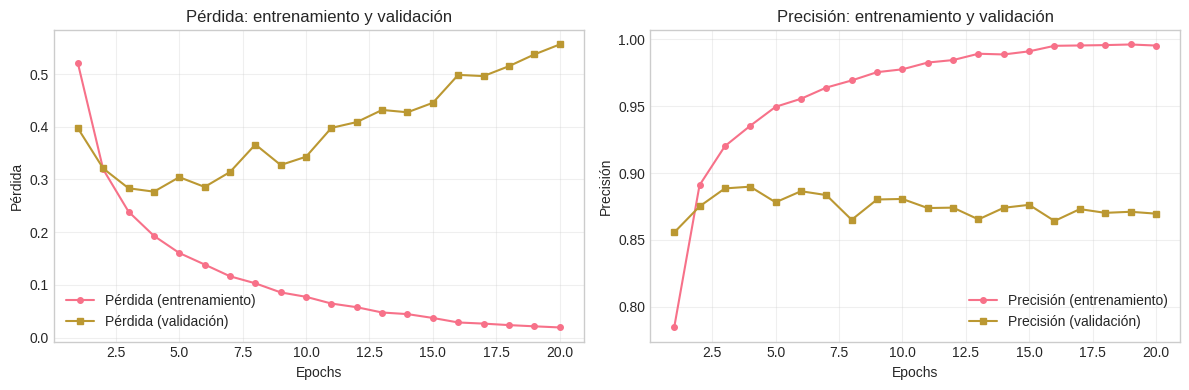

In [28]:
# Historial: pérdida y precisión
history_dict = history.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
# Mejor época (menor pérdida en validación); útil para parada temprana
best_epoch = np.argmin(val_loss) + 1
print(f"Mejor época (menor pérdida en validación): {best_epoch}")


Mejor época (menor pérdida en validación): 4


Para mitigar el sobreajuste observado, reentrenamos el modelo con un número de épocas reducido (4, basado en el análisis de las curvas de pérdida). Luego, evaluamos el modelo final en el conjunto de prueba (`x_test`, `y_test`), que el modelo no ha visto en ningún momento del entrenamiento o validación. Esto nos da una estimación imparcial de su rendimiento en datos completamente nuevos.


Los puntos son pérdida y precisión de **entrenamiento**; las líneas continuas, las de **validación**.

La pérdida de entrenamiento baja en cada época y la precisión de entrenamiento sube: es lo esperable con descenso por gradientes. **No** ocurre lo mismo con validación: suelen alcanzar un máximo hacia la cuarta época. Esto ilustra el aviso anterior: un modelo que mejora en entrenamiento no siempre generaliza mejor. En rigor, aparece **sobreajuste** (*overfitting*): tras cierta época optimizamos demasiado el entrenamiento y aprendemos representaciones específicas que no generalizan fuera de él.

Para mitigarlo, podríamos parar tras unas pocas épocas. En general hay muchas técnicas anti-sobreajuste (se verán más adelante).

Entrenemos una red nueva desde cero durante **cuatro** épocas y evaluemos en el conjunto de prueba:


Los `results` muestran la pérdida y la precisión del modelo en el conjunto de prueba. En este caso, el modelo alcanza un 88% de precisión, que es un buen punto de partida para un modelo de clasificación de sentimientos.

In [30]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)


Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8155 - loss: 0.4693
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9050 - loss: 0.2724
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9242 - loss: 0.2123
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9341 - loss: 0.1821
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8853 - loss: 0.2876


In [31]:
results


[0.28755298256874084, 0.8852800130844116]

Una vez entrenado, el modelo puede usarse para hacer predicciones en datos nuevos. `model.predict(x_test)` devuelve las probabilidades de que cada reseña en `x_test` sea positiva.

Este enfoque relativamente simple alcanza alrededor del **88 %** de precisión. Con métodos más avanzados se puede acercar al **95 %**.


## Usar la red entrenada para predecir datos nuevos

Tras entrenar, interesa desplegar el modelo. La probabilidad de que una comentario sea positiva se obtiene con `predict`:


Esta sección proporciona una visualización exhaustiva de las predicciones del modelo, lo que es esencial para entender su comportamiento más allá de una simple métrica de precisión:

1.  **Matriz de confusión**: Muestra el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. Es fundamental para evaluar el rendimiento en cada clase.
2.  **Curva ROC y AUC**: La curva `Receiver Operating Characteristic` (ROC) y el `Area Under the Curve` (AUC) son métricas clave para evaluadores binarios. `AUC` mide la capacidad del modelo para distinguir entre clases.
3.  **Distribución de probabilidades predichas**: Muestra cómo se distribuyen las probabilidades predichas para las clases reales. Idealmente, las probabilidades para los negativos deberían estar cerca de 0 y para los positivos cerca de 1.
4.  **Predicciones correctas vs. incorrectas**: Un scatter plot que visualiza la confianza del modelo en sus predicciones y dónde comete errores.

In [32]:
# Predicciones (probabilidades)
predictions = model.predict(x_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Visualización de la evaluación del modelo

A continuación se visualizan las predicciones: matriz de confusión, curva ROC, distribución de probabilidades y aciertos frente a errores.


Como ves, la red es muy segura en algunas muestras (0,99 o más, o 0,01 o menos) y menos segura en otras (0,6, 0,4).


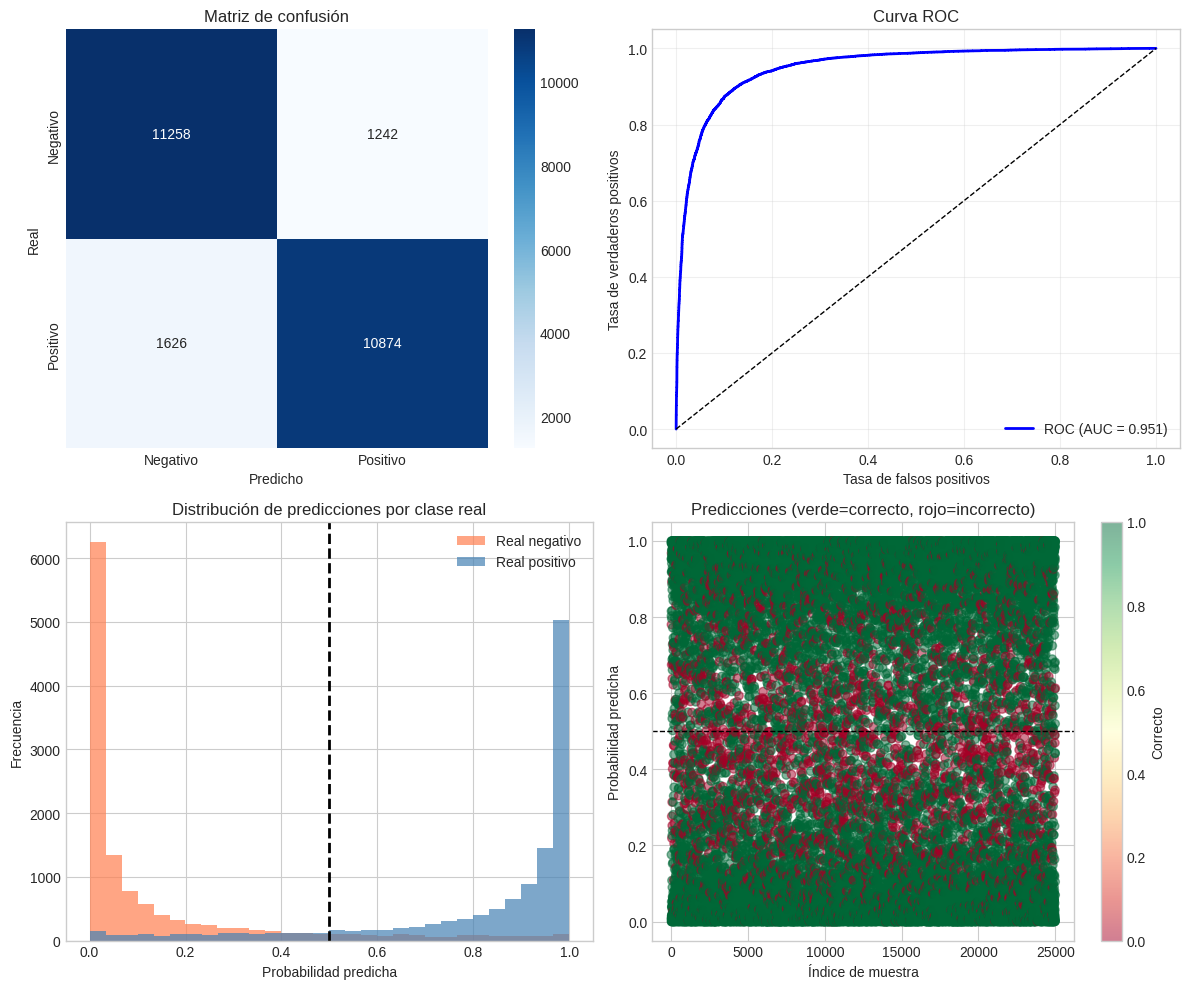

In [33]:
# Visualización de predicciones
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
axes[0, 0].set_xlabel('Predicho')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_title('Matriz de confusión')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('Tasa de falsos positivos')
axes[0, 1].set_ylabel('Tasa de verdaderos positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de probabilidades predichas por clase real
axes[1, 0].hist(predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Real negativo', color='coral')
axes[1, 0].hist(predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Real positivo', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Probabilidad predicha')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de predicciones por clase real')
axes[1, 0].legend()

# 4. Predicciones correctas vs incorrectas
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(predictions)), predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Índice de muestra')
axes[1, 1].set_ylabel('Probabilidad predicha')
axes[1, 1].set_title('Predicciones (verde=correcto, rojo=incorrecto)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correcto')

plt.tight_layout()
plt.show()


# Regularizers

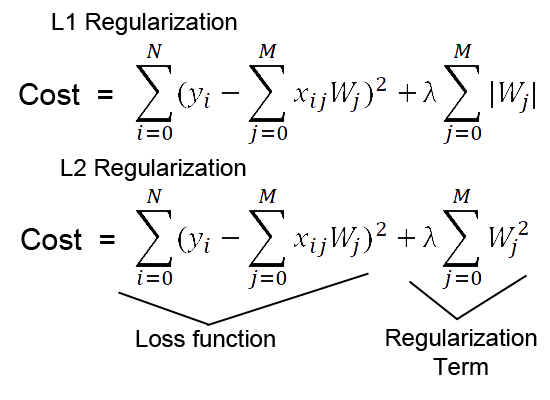

# L2

In [34]:
from keras import regularizers
l2_model = models.Sequential()
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),activation='relu', input_shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

l2_model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
l2_model_history = l2_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.7810 - loss: 0.6170 - val_accuracy: 0.8407 - val_loss: 0.5124
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8825 - loss: 0.4256 - val_accuracy: 0.8763 - val_loss: 0.3960
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9075 - loss: 0.3366 - val_accuracy: 0.8795 - val_loss: 0.3625
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9223 - loss: 0.2874 - val_accuracy: 0.8809 - val_loss: 0.3504
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9287 - loss: 0.2601 - val_accuracy: 0.8878 - val_loss: 0.3342
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9390 - loss: 0.2384 - val_accuracy: 0.8859 - val_loss: 0.3383
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9465 - loss: 0.2218 - val_accuracy: 0.8865 - val_loss: 0.3410
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9491 - loss: 0.2122 - val_accuracy: 0.8837 - v

In [36]:
l2_model_history_dict = l2_model_history.history
l2_model_history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

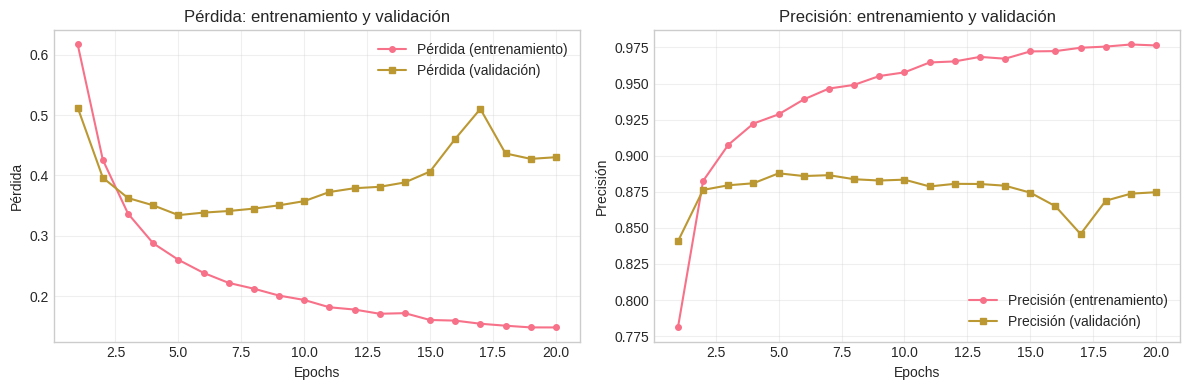

In [37]:
# Historial: pérdida y precisión
l2_model_history_dict = l2_model_history.history
l2_loss = l2_model_history_dict['loss']
l2_val_loss = l2_model_history_dict['val_loss']
l2_acc = l2_model_history_dict['accuracy']
l2_val_acc = l2_model_history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l2_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l2_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l2_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l2_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Comparación Modelo Original vs L2

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

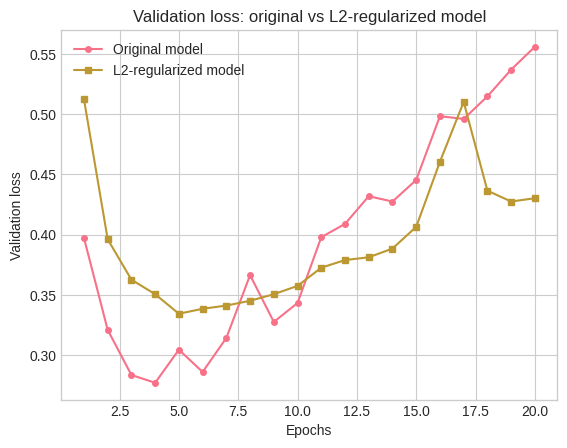

In [38]:
l2_model_val_loss=l2_model_history_dict['val_loss']
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: original vs L2-regularized model')
plt.legend()
plt

# L1 Regularizer

In [39]:
from keras import regularizers
l1_model = models.Sequential()
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.001),activation='relu', input_shape=(10000,)))
l1_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1(0.001), activation='relu'))
l1_model.add(layers.Dense(1, activation='sigmoid'))

l1_model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [40]:
l1_model_history = l1_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7307 - loss: 1.1570 - val_accuracy: 0.8125 - val_loss: 0.7383
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8177 - loss: 0.6955 - val_accuracy: 0.8466 - val_loss: 0.6623
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8411 - loss: 0.6401 - val_accuracy: 0.8373 - val_loss: 0.6425
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8500 - loss: 0.6086 - val_accuracy: 0.8038 - val_loss: 0.6752
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8514 - loss: 0.5962 - val_accuracy: 0.8511 - val_loss: 0.5983
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8509 - loss: 0.5843 - val_accuracy: 0.8561 - val_loss: 0.5838
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8637 - loss: 0.5647 - val_accuracy: 0.8606 - val_loss: 0.5730
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8579 - loss: 0.5619 - val_accuracy: 0.8629 - v

In [41]:
l1_model_history_dict = l1_model_history.history
l1_model_history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

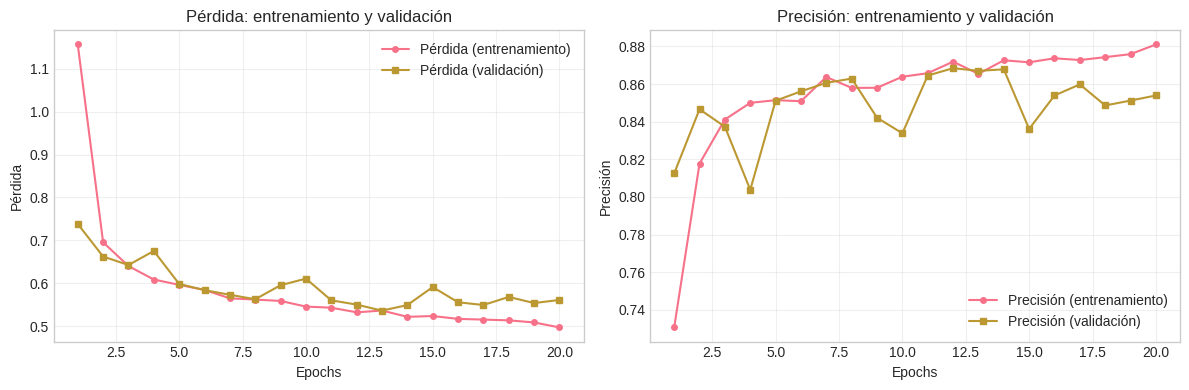

In [42]:
# Historial: pérdida y precisión
l1_model_history_dict = l1_model_history.history
l1_loss = l1_model_history_dict['loss']
l1_val_loss = l1_model_history_dict['val_loss']
l1_acc = l1_model_history_dict['accuracy']
l1_val_acc = l1_model_history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación Modelo Original vs L1

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

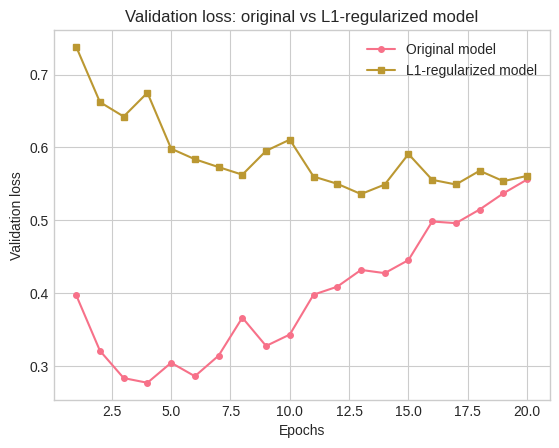

In [43]:
l1_model_val_loss=l1_model_history_dict['val_loss']
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l1_val_loss, 's-', label='L1-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: original vs L1-regularized model')
plt.legend()
plt

In [44]:
# Predicciones (probabilidades)
l1_predictions = l1_model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Visualization Predictions L1

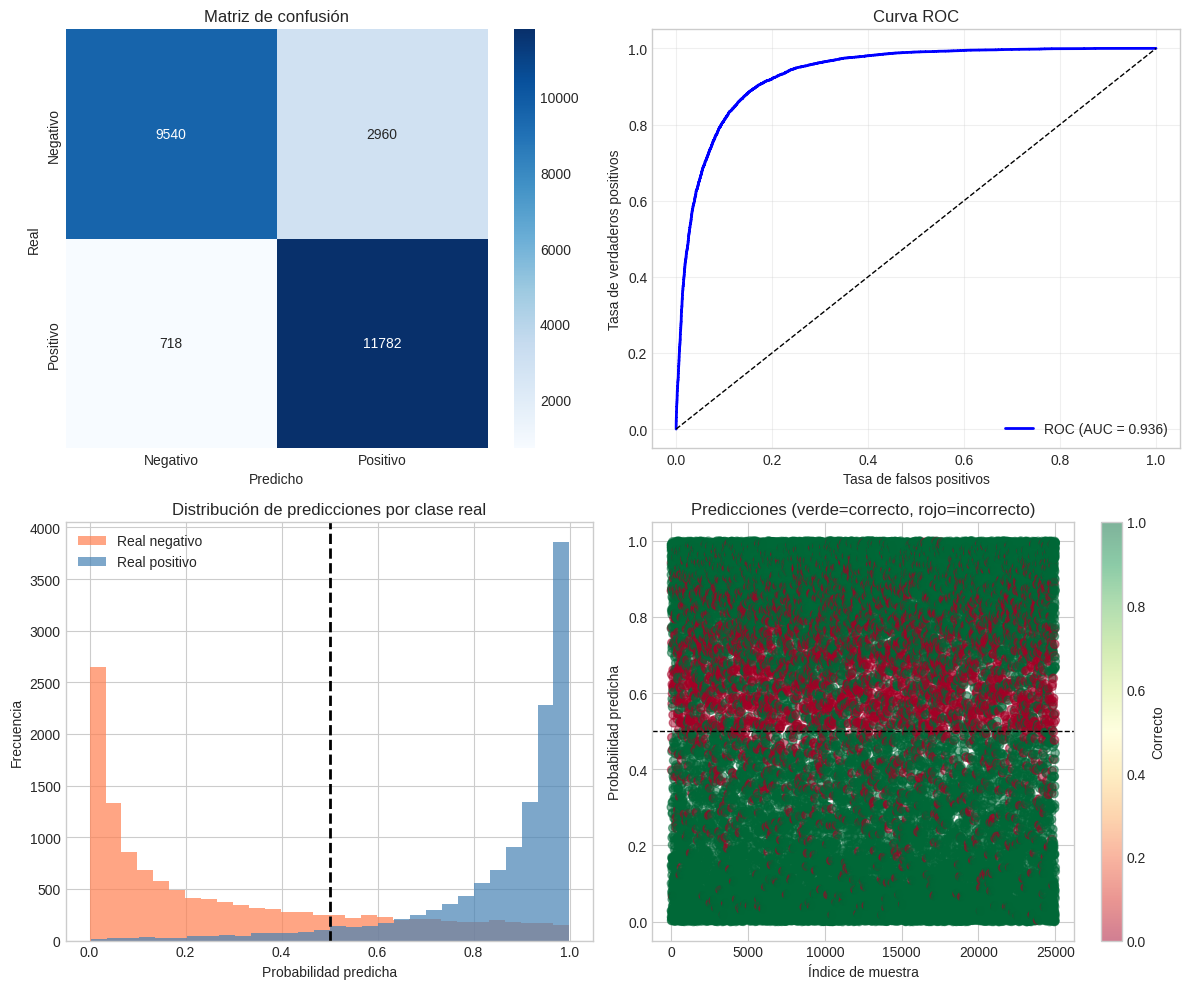

In [45]:
# Visualización de predicciones
from sklearn.metrics import confusion_matrix, roc_curve, auc

pred_classes = (l1_predictions.flatten() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Matriz de confusión
cm = confusion_matrix(y_test, pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
axes[0, 0].set_xlabel('Predicho')
axes[0, 0].set_ylabel('Real')
axes[0, 0].set_title('Matriz de confusión')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, l1_predictions.flatten())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('Tasa de falsos positivos')
axes[0, 1].set_ylabel('Tasa de verdaderos positivos')
axes[0, 1].set_title('Curva ROC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribución de probabilidades predichas por clase real
axes[1, 0].hist(l1_predictions[y_test == 0].flatten(), bins=30, alpha=0.7, label='Real negativo', color='coral')
axes[1, 0].hist(l1_predictions[y_test == 1].flatten(), bins=30, alpha=0.7, label='Real positivo', color='steelblue')
axes[1, 0].axvline(x=0.5, color='black', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Probabilidad predicha')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de predicciones por clase real')
axes[1, 0].legend()

# 4. Predicciones correctas vs incorrectas
correct = pred_classes == y_test
axes[1, 1].scatter(range(len(l1_predictions)), l1_predictions.flatten(), c=correct, cmap='RdYlGn', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='black', linestyle='--', lw=1)
axes[1, 1].set_xlabel('Índice de muestra')
axes[1, 1].set_ylabel('Probabilidad predicha')
axes[1, 1].set_title('Predicciones (verde=correcto, rojo=incorrecto)')
plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Correcto')

plt.tight_layout()
plt.show()

In [46]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define the L2 regularized model again
l2_model_early_stopping = models.Sequential()
l2_model_early_stopping.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu', input_shape=(10000,)))
l2_model_early_stopping.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001), activation='relu'))
l2_model_early_stopping.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
l2_model_early_stopping.compile(optimizer='rmsprop',
                                loss='binary_crossentropy',
                                metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor the validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the model with early stopping
l2_model_early_stopping_history = l2_model_early_stopping.fit(partial_x_train,
                                                               partial_y_train,
                                                               epochs=20, # Train for a sufficient number of epochs, early stopping will stop it earlier if needed
                                                               batch_size=512,
                                                               validation_data=(x_val, y_val),
                                                               callbacks=[early_stopping])

# Evaluate the model on the test data
results_early_stopping = l2_model_early_stopping.evaluate(x_test, y_test)
print(f"Test Loss: {results_early_stopping[0]:.4f}, Test Accuracy: {results_early_stopping[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7774 - loss: 0.5665 - val_accuracy: 0.8663 - val_loss: 0.4426
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8954 - loss: 0.3704 - val_accuracy: 0.8738 - val_loss: 0.3779
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9159 - loss: 0.2968 - val_accuracy: 0.8890 - val_loss: 0.3360
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9297 - loss: 0.2596 - val_accuracy: 0.8859 - val_loss: 0.3397
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9388 - loss: 0.2355 - val_accuracy: 0.8853 - val_loss: 0.3331
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9453 - loss: 0.2178 - val_accuracy: 0.8848 - val_loss: 0.3367
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9515 - loss: 0.2026 - val_accuracy: 0.8831 - val_loss: 0.3471
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9530 - loss: 0.1967 - val_accuracy: 0.8842 - v

### Training History with Early Stopping

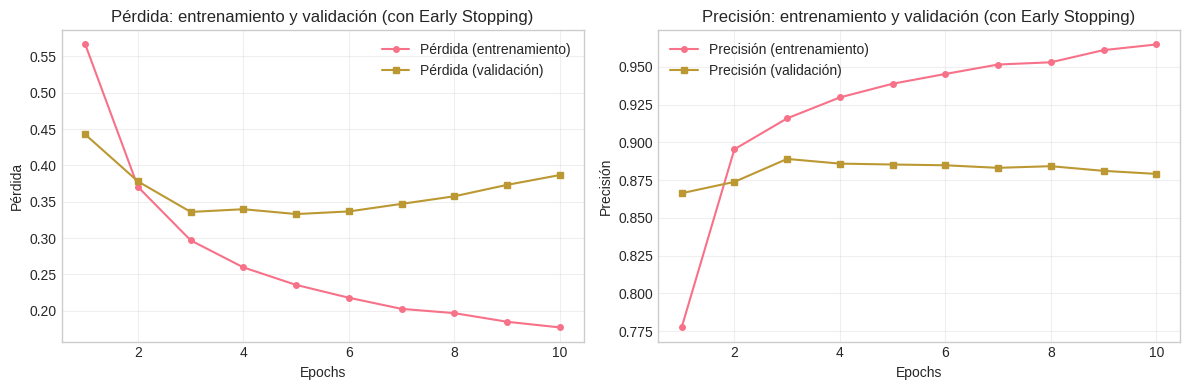

In [47]:
# Historial: pérdida y precisión con Early Stopping
callbacks_history_dict = l2_model_early_stopping_history.history
callbacks_loss = callbacks_history_dict['loss']
callbacks_val_loss = callbacks_history_dict['val_loss']
callbacks_acc = callbacks_history_dict['accuracy']
callbacks_val_acc = callbacks_history_dict['val_accuracy']
epochs = range(1, len(callbacks_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, callbacks_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, callbacks_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (con Early Stopping)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, callbacks_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, callbacks_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (con Early Stopping)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Dropout Regularization

In [48]:
from tensorflow.keras import models
from tensorflow.keras import layers

dropout_model = models.Sequential()
dropout_model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dropout_model.add(layers.Dropout(0.5)) # Add dropout layer with a rate of 0.5
dropout_model.add(layers.Dense(16, activation='relu'))
dropout_model.add(layers.Dropout(0.5)) # Add another dropout layer
dropout_model.add(layers.Dense(1, activation='sigmoid'))

dropout_model.compile(optimizer='rmsprop',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

In [49]:
dropout_model_history = dropout_model.fit(partial_x_train,
                                          partial_y_train,
                                          epochs=20,
                                          batch_size=512,
                                          validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6079 - loss: 0.6555 - val_accuracy: 0.7591 - val_loss: 0.5787
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7381 - loss: 0.5627 - val_accuracy: 0.8611 - val_loss: 0.4794
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8034 - loss: 0.4831 - val_accuracy: 0.8640 - val_loss: 0.4026
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8457 - loss: 0.4167 - val_accuracy: 0.8806 - val_loss: 0.3536
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8732 - loss: 0.3687 - val_accuracy: 0.8870 - val_loss: 0.3128
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8889 - loss: 0.3284 - val_accuracy: 0.8885 - val_loss: 0.2951
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9054 - loss: 0.2934 - val_accuracy: 0.8846 - val_loss: 0.2861
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9155 - loss: 0.2671 - val_accuracy: 0.8904 - v

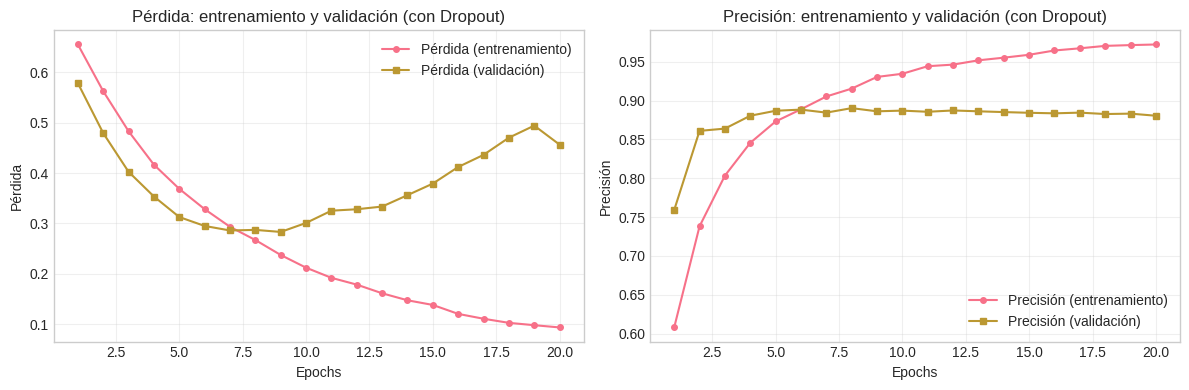

In [50]:
# Historial: pérdida y precisión para el modelo con Dropout
dropout_history_dict = dropout_model_history.history
dropout_loss = dropout_history_dict['loss']
dropout_val_loss = dropout_history_dict['val_loss']
dropout_acc = dropout_history_dict['accuracy']
dropout_val_acc = dropout_history_dict['val_accuracy']
epochs = range(1, len(dropout_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, dropout_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, dropout_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (con Dropout)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, dropout_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, dropout_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (con Dropout)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación de Modelos: Original vs L2 vs Dropout

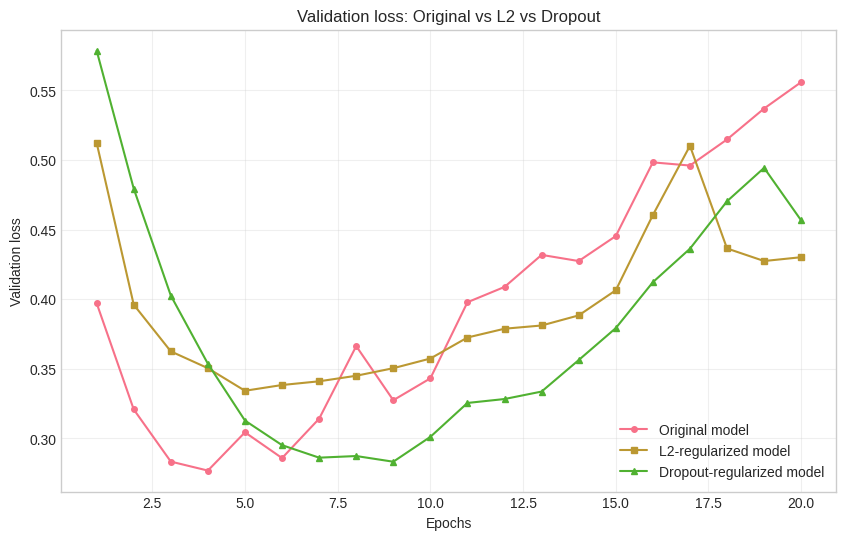

In [51]:
dropout_val_loss = dropout_history_dict['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss, '^-', label='Dropout-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: Original vs L2 vs Dropout')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#**Tarea Problema 2**

In [52]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers

# Crear un nuevo modelo basado en el original, agregando regularizaciones L1 y L2
l1_l2_model = models.Sequential()
l1_l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001), activation='relu', input_shape=(10000,)))
l1_l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001), activation='relu'))
l1_l2_model.add(layers.Dense(1, activation='sigmoid'))

# Compilar el modelo
l1_l2_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

l1_l2_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
l1_l2_model_history = l1_l2_model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.7465 - loss: 1.1672 - val_accuracy: 0.8339 - val_loss: 0.7292
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8461 - loss: 0.6788 - val_accuracy: 0.8559 - val_loss: 0.6505
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8586 - loss: 0.6223 - val_accuracy: 0.8525 - val_loss: 0.6199
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8634 - loss: 0.5877 - val_accuracy: 0.8578 - val_loss: 0.5917
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8645 - loss: 0.5709 - val_accuracy: 0.8648 - val_loss: 0.5779
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8724 - loss: 0.5539 - val_accuracy: 0.8666 - val_loss: 0.5644
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8703 - loss: 0.5477 - val_accuracy: 0.8664 - val_loss: 0.5573
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8714 - loss: 0.5370 - val_accuracy: 0.8608 - v

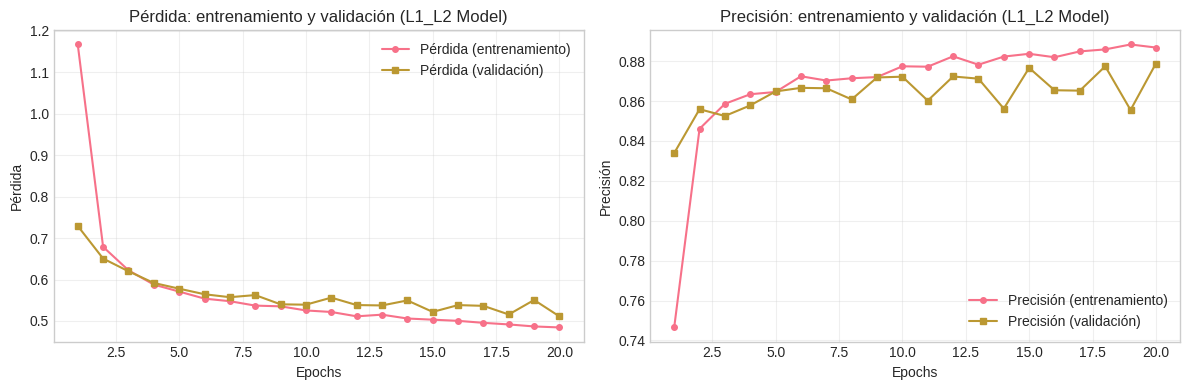

In [54]:
l1_l2_model_history_dict = l1_l2_model_history.history
l1_l2_loss = l1_l2_model_history_dict['loss']
l1_l2_val_loss = l1_l2_model_history_dict['val_loss']
l1_l2_acc = l1_l2_model_history_dict['accuracy']
l1_l2_val_acc = l1_l2_model_history_dict['val_accuracy']
epochs = range(1, len(l1_l2_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_l2_loss, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_l2_val_loss, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (L1_L2 Model)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_l2_acc, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_l2_val_acc, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (L1_L2 Model)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#**Tarea Problema 3**

## Prueba 1: Regularización L1 (0.01) y L2 (0.01)

In [55]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers

# Crear un nuevo modelo con regularización L1 y L2 (0.01, 0.01)
l1_l2_model_01_01 = models.Sequential()
l1_l2_model_01_01.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu', input_shape=(10000,)))
l1_l2_model_01_01.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01), activation='relu'))
l1_l2_model_01_01.add(layers.Dense(1, activation='sigmoid'))

# Compilar el modelo
l1_l2_model_01_01.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

l1_l2_model_01_01.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
l1_l2_model_01_01_history = l1_l2_model_01_01.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.5808 - loss: 5.1142 - val_accuracy: 0.6549 - val_loss: 2.0958
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6545 - loss: 2.0462 - val_accuracy: 0.5508 - val_loss: 1.9924
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6766 - loss: 1.9491 - val_accuracy: 0.6289 - val_loss: 1.9058
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6896 - loss: 1.8675 - val_accuracy: 0.7463 - val_loss: 1.8247
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7084 - loss: 1.7969 - val_accuracy: 0.7474 - val_loss: 1.7577
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7291 - loss: 1.7323 - val_accuracy: 0.7553 - val_loss: 1.6974
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7433 - loss: 1.6762 - val_accuracy: 0.7521 - val_loss: 1.6475
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7556 - loss: 1.6235 - val_accuracy: 0.7642 - v

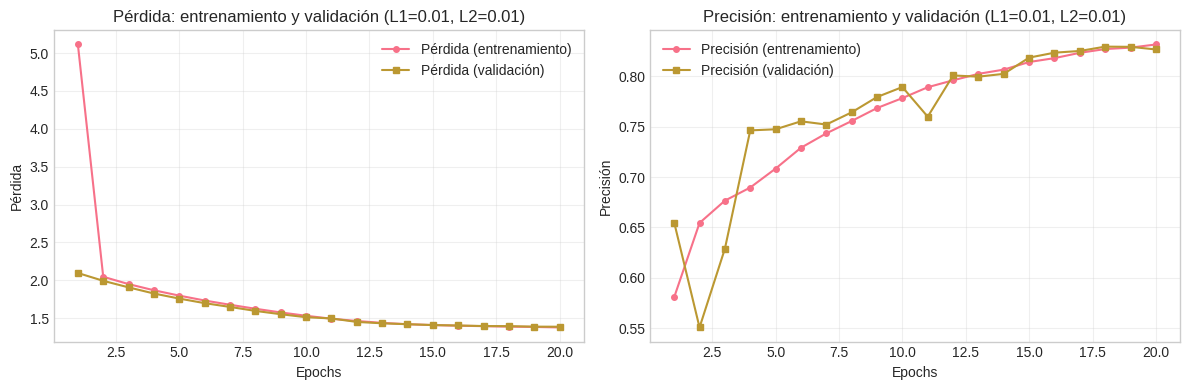

In [57]:
# Historial: pérdida y precisión para L1(0.01) y L2(0.01)
l1_l2_history_dict_01_01 = l1_l2_model_01_01_history.history
l1_l2_loss_01_01 = l1_l2_history_dict_01_01['loss']
l1_l2_val_loss_01_01 = l1_l2_history_dict_01_01['val_loss']
l1_l2_acc_01_01 = l1_l2_history_dict_01_01['accuracy']
l1_l2_val_acc_01_01 = l1_l2_history_dict_01_01['val_accuracy']
epochs = range(1, len(l1_l2_loss_01_01) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_l2_loss_01_01, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_l2_val_loss_01_01, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (L1=0.01, L2=0.01)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_l2_acc_01_01, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_l2_val_acc_01_01, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (L1=0.01, L2=0.01)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

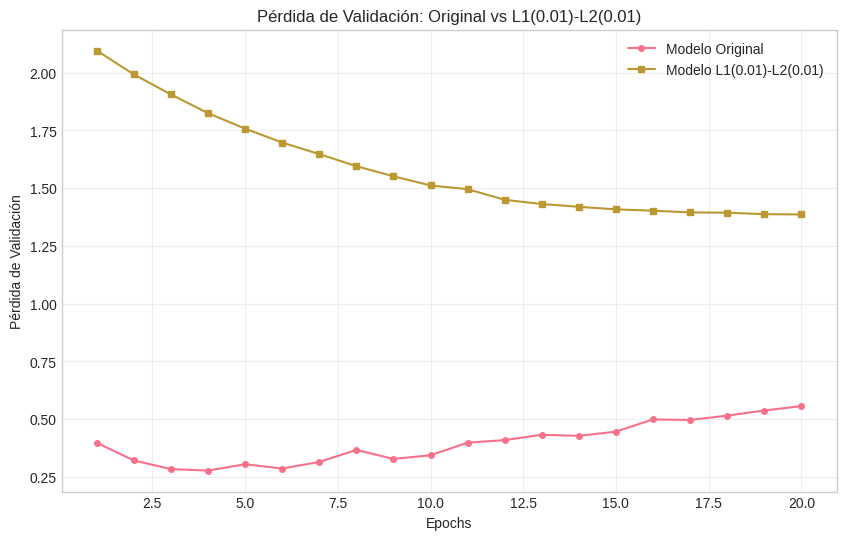

Menor pérdida de validación (Original): 0.2768 en época 4
Menor pérdida de validación (L1=0.01, L2=0.01): 1.3860 en época 20


In [58]:
# Comparación de la pérdida de validación con el modelo original
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss, 'o-', label='Modelo Original', markersize=4)
plt.plot(epochs, l1_l2_val_loss_01_01, 's-', label='Modelo L1(0.01)-L2(0.01)', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Pérdida de Validación')
plt.title('Pérdida de Validación: Original vs L1(0.01)-L2(0.01)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Menor pérdida de validación (Original): {min(val_loss):.4f} en época {np.argmin(val_loss) + 1}")
print(f"Menor pérdida de validación (L1=0.01, L2=0.01): {min(l1_l2_val_loss_01_01):.4f} en época {np.argmin(l1_l2_val_loss_01_01) + 1}")

## Prueba 2: Regularización L1 (0.02) y L2 (0.02)

In [59]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers

# Crear un nuevo modelo con regularización L1 y L2 (0.02, 0.02)
l1_l2_model_02_02 = models.Sequential()
l1_l2_model_02_02.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.02, l2=0.02), activation='relu', input_shape=(10000,)))
l1_l2_model_02_02.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.02, l2=0.02), activation='relu'))
l1_l2_model_02_02.add(layers.Dense(1, activation='sigmoid'))

# Compilar el modelo
l1_l2_model_02_02.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

l1_l2_model_02_02.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
l1_l2_model_02_02_history = l1_l2_model_02_02.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.4939 - loss: 9.5466 - val_accuracy: 0.4939 - val_loss: 3.4908
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5013 - loss: 3.4184 - val_accuracy: 0.4946 - val_loss: 3.2732
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5035 - loss: 3.2291 - val_accuracy: 0.4947 - val_loss: 3.1037
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5035 - loss: 3.0662 - val_accuracy: 0.4947 - val_loss: 2.9540
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5037 - loss: 2.9221 - val_accuracy: 0.5100 - val_loss: 2.8209
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5053 - loss: 2.7948 - val_accuracy: 0.5237 - val_loss: 2.7061
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5062 - loss: 2.6841 - val_accuracy: 0.5193 - val_loss: 2.6045
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5188 - loss: 2.5869 - val_accuracy: 0.4947 - v

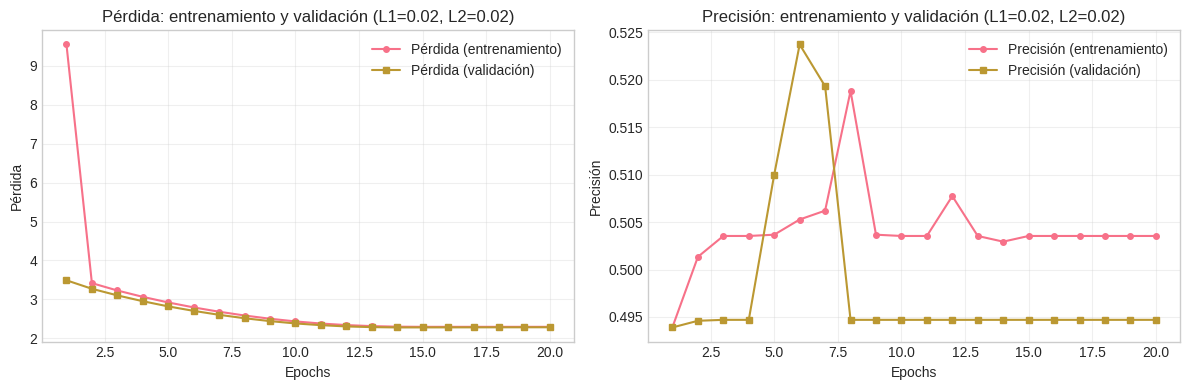

In [61]:
# Historial: pérdida y precisión para L1(0.02) y L2(0.02)
l1_l2_history_dict_02_02 = l1_l2_model_02_02_history.history
l1_l2_loss_02_02 = l1_l2_history_dict_02_02['loss']
l1_l2_val_loss_02_02 = l1_l2_history_dict_02_02['val_loss']
l1_l2_acc_02_02 = l1_l2_history_dict_02_02['accuracy']
l1_l2_val_acc_02_02 = l1_l2_history_dict_02_02['val_accuracy']
epochs = range(1, len(l1_l2_loss_02_02) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_l2_loss_02_02, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_l2_val_loss_02_02, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (L1=0.02, L2=0.02)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_l2_acc_02_02, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_l2_val_acc_02_02, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (L1=0.02, L2=0.02)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

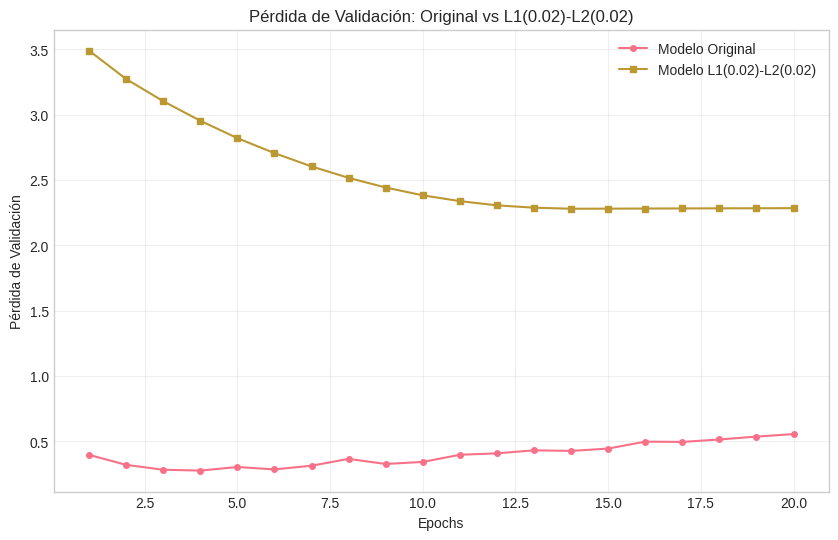

Menor pérdida de validación (Original): 0.2768 en época 4
Menor pérdida de validación (L1=0.02, L2=0.02): 2.2805 en época 14


In [62]:
# Comparación de la pérdida de validación con el modelo original
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss, 'o-', label='Modelo Original', markersize=4)
plt.plot(epochs, l1_l2_val_loss_02_02, 's-', label='Modelo L1(0.02)-L2(0.02)', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Pérdida de Validación')
plt.title('Pérdida de Validación: Original vs L1(0.02)-L2(0.02)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Menor pérdida de validación (Original): {min(val_loss):.4f} en época {np.argmin(val_loss) + 1}")
print(f"Menor pérdida de validación (L1=0.02, L2=0.02): {min(l1_l2_val_loss_02_02):.4f} en época {np.argmin(l1_l2_val_loss_02_02) + 1}")

## Prueba 3: Regularización L1 (0.01) y L2 (0.02)

In [63]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers

# Crear un nuevo modelo con regularización L1 (0.01) y L2 (0.02)
l1_l2_model_01_02 = models.Sequential()
l1_l2_model_01_02.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.02), activation='relu', input_shape=(10000,)))
l1_l2_model_01_02.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.02), activation='relu'))
l1_l2_model_01_02.add(layers.Dense(1, activation='sigmoid'))

# Compilar el modelo
l1_l2_model_01_02.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

l1_l2_model_01_02.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
l1_l2_model_01_02_history = l1_l2_model_01_02.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.5788 - loss: 5.2862 - val_accuracy: 0.6761 - val_loss: 2.1836
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6470 - loss: 2.1309 - val_accuracy: 0.7541 - val_loss: 2.0527
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6639 - loss: 2.0142 - val_accuracy: 0.5970 - val_loss: 1.9626
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6939 - loss: 1.9146 - val_accuracy: 0.7037 - val_loss: 1.8655
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7090 - loss: 1.8269 - val_accuracy: 0.7202 - val_loss: 1.7843
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7352 - loss: 1.7485 - val_accuracy: 0.7661 - val_loss: 1.7083
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7528 - loss: 1.6789 - val_accuracy: 0.7674 - val_loss: 1.6481
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7575 - loss: 1.6192 - val_accuracy: 0.7661 - v

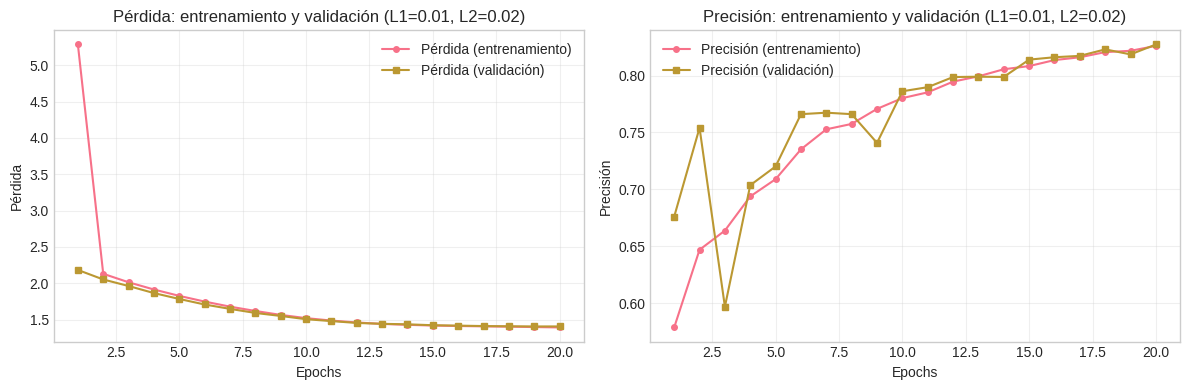

In [65]:
# Historial: pérdida y precisión para L1(0.01) y L2(0.02)
l1_l2_history_dict_01_02 = l1_l2_model_01_02_history.history
l1_l2_loss_01_02 = l1_l2_history_dict_01_02['loss']
l1_l2_val_loss_01_02 = l1_l2_history_dict_01_02['val_loss']
l1_l2_acc_01_02 = l1_l2_history_dict_01_02['accuracy']
l1_l2_val_acc_01_02 = l1_l2_history_dict_01_02['val_accuracy']
epochs = range(1, len(l1_l2_loss_01_02) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_l2_loss_01_02, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_l2_val_loss_01_02, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (L1=0.01, L2=0.02)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_l2_acc_01_02, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_l2_val_acc_01_02, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (L1=0.01, L2=0.02)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

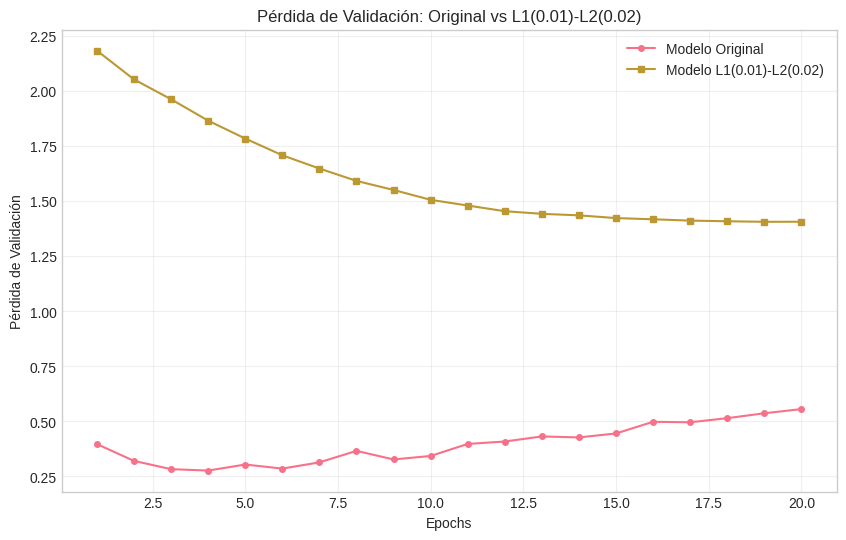

Menor pérdida de validación (Original): 0.2768 en época 4
Menor pérdida de validación (L1=0.01, L2=0.02): 1.4063 en época 19


In [66]:
# Comparación de la pérdida de validación con el modelo original
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss, 'o-', label='Modelo Original', markersize=4)
plt.plot(epochs, l1_l2_val_loss_01_02, 's-', label='Modelo L1(0.01)-L2(0.02)', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Pérdida de Validación')
plt.title('Pérdida de Validación: Original vs L1(0.01)-L2(0.02)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Menor pérdida de validación (Original): {min(val_loss):.4f} en época {np.argmin(val_loss) + 1}")
print(f"Menor pérdida de validación (L1=0.01, L2=0.02): {min(l1_l2_val_loss_01_02):.4f} en época {np.argmin(l1_l2_val_loss_01_02) + 1}")

## Prueba 4: Regularización L1 (0.02) y L2 (0.01)

In [67]:
from tensorflow.keras import models
from tensorflow.keras import layers
from keras import regularizers

# Crear un nuevo modelo con regularización L1 (0.02) y L2 (0.01)
l1_l2_model_02_01 = models.Sequential()
l1_l2_model_02_01.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.02, l2=0.01), activation='relu', input_shape=(10000,)))
l1_l2_model_02_01.add(layers.Dense(16, kernel_regularizer=regularizers.l1_l2(l1=0.02, l2=0.01), activation='relu'))
l1_l2_model_02_01.add(layers.Dense(1, activation='sigmoid'))

# Compilar el modelo
l1_l2_model_02_01.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

l1_l2_model_02_01.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
l1_l2_model_02_01_history = l1_l2_model_02_01.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.5253 - loss: 9.3778 - val_accuracy: 0.6534 - val_loss: 3.3950
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5420 - loss: 3.3218 - val_accuracy: 0.4947 - val_loss: 3.2023
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5942 - loss: 3.1541 - val_accuracy: 0.6752 - val_loss: 3.0515
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5827 - loss: 3.0125 - val_accuracy: 0.5576 - val_loss: 2.9214
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6095 - loss: 2.8831 - val_accuracy: 0.5051 - val_loss: 2.7987
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5652 - loss: 2.7666 - val_accuracy: 0.6559 - val_loss: 2.6917
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5260 - loss: 2.6650 - val_accuracy: 0.5221 - val_loss: 2.5994
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5231 - loss: 2.5784 - val_accuracy: 0.5488 - v

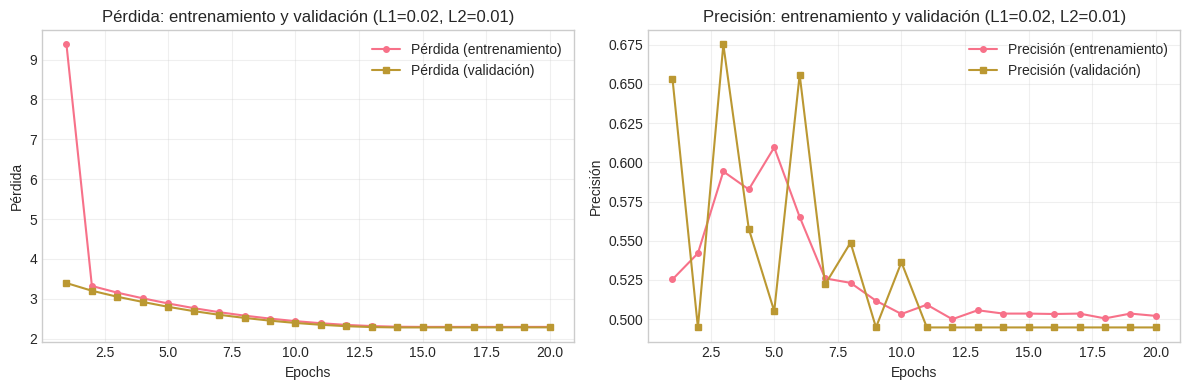

In [69]:
# Historial: pérdida y precisión para L1(0.02) y L2(0.01)
l1_l2_history_dict_02_01 = l1_l2_model_02_01_history.history
l1_l2_loss_02_01 = l1_l2_history_dict_02_01['loss']
l1_l2_val_loss_02_01 = l1_l2_history_dict_02_01['val_loss']
l1_l2_acc_02_01 = l1_l2_history_dict_02_01['accuracy']
l1_l2_val_acc_02_01 = l1_l2_history_dict_02_01['val_accuracy']
epochs = range(1, len(l1_l2_loss_02_01) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, l1_l2_loss_02_01, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, l1_l2_val_loss_02_01, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (L1=0.02, L2=0.01)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, l1_l2_acc_02_01, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, l1_l2_val_acc_02_01, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (L1=0.02, L2=0.01)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

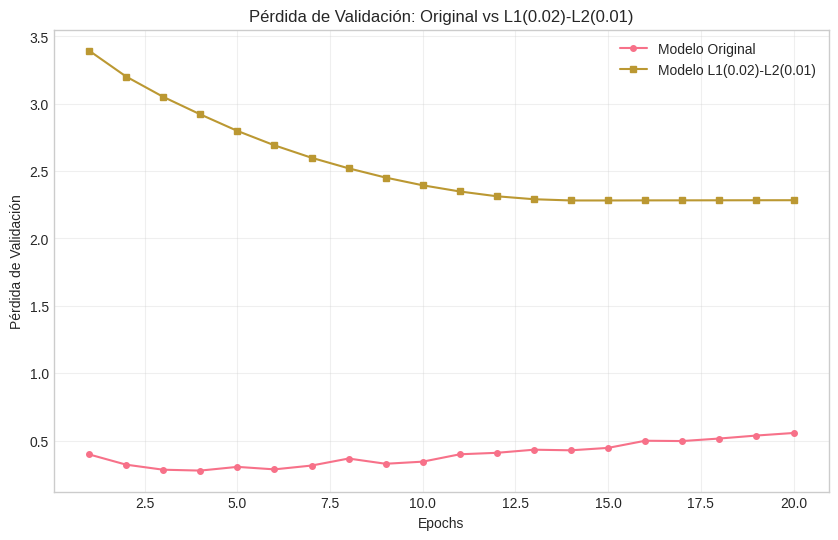

Menor pérdida de validación (Original): 0.2768 en época 4
Menor pérdida de validación (L1=0.02, L2=0.01): 2.2822 en época 15


In [70]:
# Comparación de la pérdida de validación con el modelo original
plt.figure(figsize=(10, 6))
plt.plot(epochs, val_loss, 'o-', label='Modelo Original', markersize=4)
plt.plot(epochs, l1_l2_val_loss_02_01, 's-', label='Modelo L1(0.02)-L2(0.01)', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Pérdida de Validación')
plt.title('Pérdida de Validación: Original vs L1(0.02)-L2(0.01)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Menor pérdida de validación (Original): {min(val_loss):.4f} en época {np.argmin(val_loss) + 1}")
print(f"Menor pérdida de validación (L1=0.02, L2=0.01): {min(l1_l2_val_loss_02_01):.4f} en época {np.argmin(l1_l2_val_loss_02_01) + 1}")

In [71]:
from tensorflow.keras import models
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Build the model with Dropout layers
dropout_model_new = models.Sequential()
dropout_model_new.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dropout_model_new.add(layers.Dropout(0.5)) # Dropout layer after the first Dense layer
dropout_model_new.add(layers.Dense(16, activation='relu'))
dropout_model_new.add(layers.Dropout(0.5)) # Dropout layer after the second Dense layer
dropout_model_new.add(layers.Dense(1, activation='sigmoid'))

# Compile the model
dropout_model_new.compile(optimizer='rmsprop',
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

# Train the model
dropout_model_history_new = dropout_model_new.fit(partial_x_train,
                                                partial_y_train,
                                                epochs=20,
                                                batch_size=512,
                                                validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.6417 - loss: 0.6310 - val_accuracy: 0.8145 - val_loss: 0.5284
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7709 - loss: 0.5158 - val_accuracy: 0.8619 - val_loss: 0.4273
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8370 - loss: 0.4350 - val_accuracy: 0.8758 - val_loss: 0.3609
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8736 - loss: 0.3692 - val_accuracy: 0.8823 - val_loss: 0.3149
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8883 - loss: 0.3266 - val_accuracy: 0.8873 - val_loss: 0.2943
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9080 - loss: 0.2879 - val_accuracy: 0.8865 - val_loss: 0.2832
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9202 - loss: 0.2526 - val_accuracy: 0.8853 - val_loss: 0.2976
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9321 - loss: 0.2236 - val_accuracy: 0.8856 - v

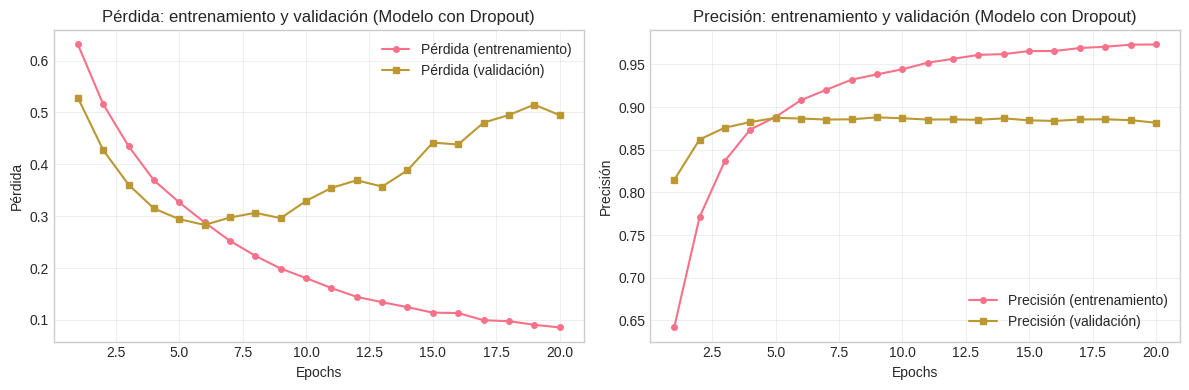

In [72]:
# Get the training history for plotting
dropout_history_dict_new = dropout_model_history_new.history
dropout_loss_new = dropout_history_dict_new['loss']
dropout_val_loss_new = dropout_history_dict_new['val_loss']
dropout_acc_new = dropout_history_dict_new['accuracy']
dropout_val_acc_new = dropout_history_dict_new['val_accuracy']
epochs_new = range(1, len(dropout_loss_new) + 1)

# Plotting the training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_new, dropout_loss_new, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs_new, dropout_val_loss_new, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (Modelo con Dropout)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_new, dropout_acc_new, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs_new, dropout_val_acc_new, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (Modelo con Dropout)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Prueba 1: Dropout Regularization (Drop 75% signal, keep 25%)

In [73]:
from tensorflow.keras import models
from tensorflow.keras import layers

dropout_model_25_signal = models.Sequential()
dropout_model_25_signal.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dropout_model_25_signal.add(layers.Dropout(0.75)) # Drop 75% of signal, keep 25%
dropout_model_25_signal.add(layers.Dense(16, activation='relu'))
dropout_model_25_signal.add(layers.Dropout(0.75)) # Drop 75% of signal, keep 25%
dropout_model_25_signal.add(layers.Dense(1, activation='sigmoid'))

dropout_model_25_signal.compile(optimizer='rmsprop',
                                loss='binary_crossentropy',
                                metrics=['accuracy'])

dropout_model_25_signal.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
dropout_model_25_signal_history = dropout_model_25_signal.fit(partial_x_train,
                                                        partial_y_train,
                                                        epochs=20,
                                                        batch_size=512,
                                                        validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5137 - loss: 0.6911 - val_accuracy: 0.6871 - val_loss: 0.6781
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5662 - loss: 0.6632 - val_accuracy: 0.8312 - val_loss: 0.6048
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5879 - loss: 0.6330 - val_accuracy: 0.8529 - val_loss: 0.5626
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6142 - loss: 0.6037 - val_accuracy: 0.8675 - val_loss: 0.5243
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.6310 - loss: 0.5831 - val_accuracy: 0.8751 - val_loss: 0.4924
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6393 - loss: 0.5636 - val_accuracy: 0.8733 - val_loss: 0.4585
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.6520 - loss: 0.5576 - val_accuracy: 0.8780 - val_loss: 0.4548
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6631 - loss: 0.5455 - val_accuracy: 0.8778 - v

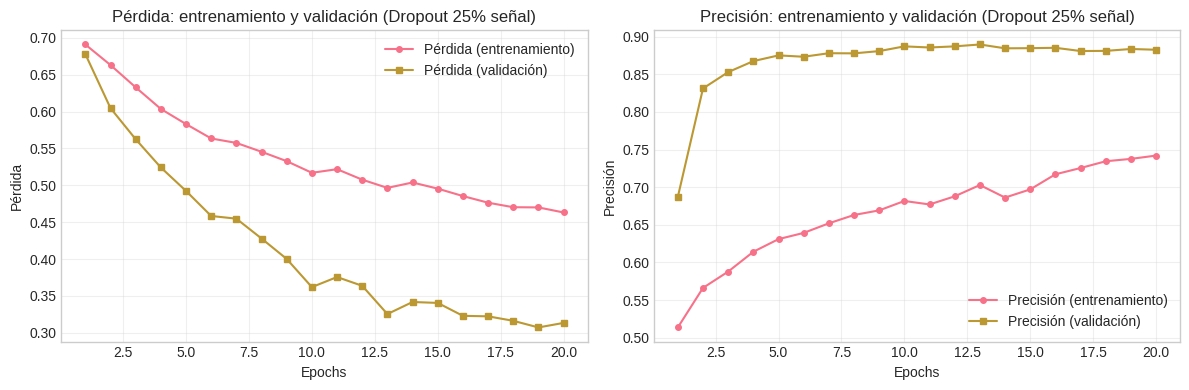

In [75]:
# Historial: pérdida y precisión para el modelo con Dropout (25% signal)
dropout_history_dict_25_signal = dropout_model_25_signal_history.history
dropout_loss_25_signal = dropout_history_dict_25_signal['loss']
dropout_val_loss_25_signal = dropout_history_dict_25_signal['val_loss']
dropout_acc_25_signal = dropout_history_dict_25_signal['accuracy']
dropout_val_acc_25_signal = dropout_history_dict_25_signal['val_accuracy']
epochs = range(1, len(dropout_loss_25_signal) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, dropout_loss_25_signal, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, dropout_val_loss_25_signal, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (Dropout 25% señal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, dropout_acc_25_signal, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, dropout_val_acc_25_signal, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (Dropout 25% señal)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Comparación de la pérdida de validación: Original vs L2 vs Dropout(0.5) vs Dropout(0.25)

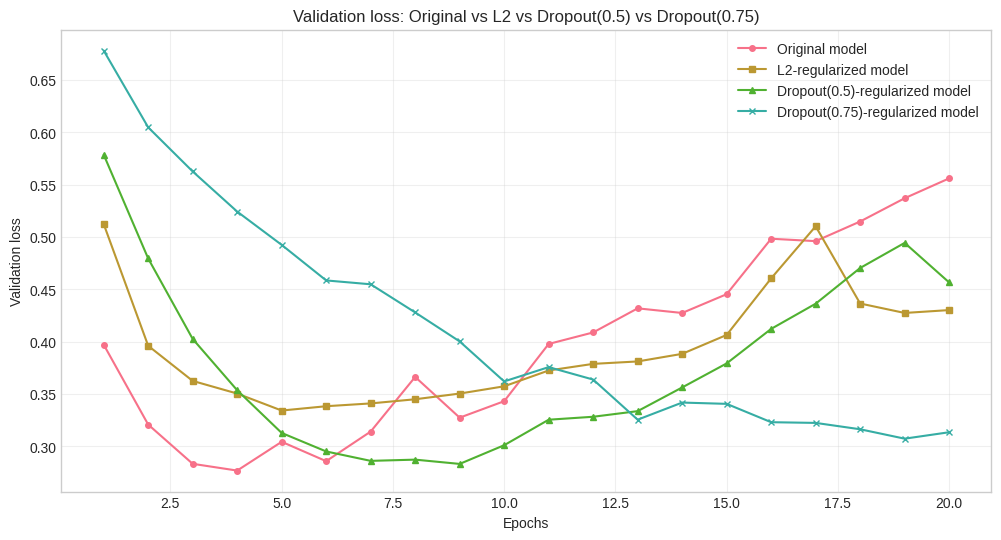

Menor pérdida de validación (Original): 0.2768 en época 4
Menor pérdida de validación (L2=0.001): 0.3342 en época 5
Menor pérdida de validación (Dropout=0.5): 0.2832 en época 9
Menor pérdida de validación (Dropout=0.75): 0.3073 en época 19


In [76]:
plt.figure(figsize=(12, 6))
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss, '^-', label='Dropout(0.5)-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss_25_signal, 'x-', label='Dropout(0.75)-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: Original vs L2 vs Dropout(0.5) vs Dropout(0.75)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Menor pérdida de validación (Original): {min(val_loss):.4f} en época {np.argmin(val_loss) + 1}")
print(f"Menor pérdida de validación (L2=0.001): {min(l2_val_loss):.4f} en época {np.argmin(l2_val_loss) + 1}")
print(f"Menor pérdida de validación (Dropout=0.5): {min(dropout_val_loss):.4f} en época {np.argmin(dropout_val_loss) + 1}")
print(f"Menor pérdida de validación (Dropout=0.75): {min(dropout_val_loss_25_signal):.4f} en época {np.argmin(dropout_val_loss_25_signal) + 1}")

## Prueba 2: Dropout Regularization (Drop 90% signal, keep 10%)

In [77]:
from tensorflow.keras import models
from tensorflow.keras import layers

dropout_model_10_signal = models.Sequential()
dropout_model_10_signal.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
dropout_model_10_signal.add(layers.Dropout(0.90)) # Drop 90% of signal, keep 10%
dropout_model_10_signal.add(layers.Dense(16, activation='relu'))
dropout_model_10_signal.add(layers.Dropout(0.90)) # Drop 90% of signal, keep 10%
dropout_model_10_signal.add(layers.Dense(1, activation='sigmoid'))

dropout_model_10_signal.compile(optimizer='rmsprop',
                                loss='binary_crossentropy',
                                metrics=['accuracy'])

dropout_model_10_signal.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
dropout_model_10_signal_history = dropout_model_10_signal.fit(partial_x_train,
                                                        partial_y_train,
                                                        epochs=20,
                                                        batch_size=512,
                                                        validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.4964 - loss: 0.7038 - val_accuracy: 0.5607 - val_loss: 0.6925
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5011 - loss: 0.6938 - val_accuracy: 0.4954 - val_loss: 0.6930
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5037 - loss: 0.6934 - val_accuracy: 0.4950 - val_loss: 0.6921
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5032 - loss: 0.6911 - val_accuracy: 0.4947 - val_loss: 0.6880
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5071 - loss: 0.6901 - val_accuracy: 0.4951 - val_loss: 0.6841
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5076 - loss: 0.6887 - val_accuracy: 0.7120 - val_loss: 0.6791
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5233 - loss: 0.6868 - val_accuracy: 0.7756 - val_loss: 0.6795
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5277 - loss: 0.6844 - val_accuracy: 0.7685 - v

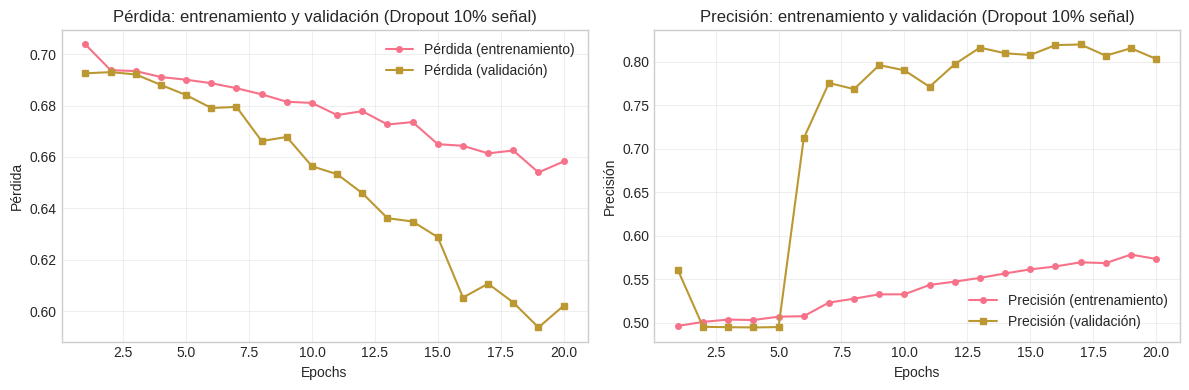

In [79]:
# Historial: pérdida y precisión para el modelo con Dropout (10% signal)
dropout_history_dict_10_signal = dropout_model_10_signal_history.history
dropout_loss_10_signal = dropout_history_dict_10_signal['loss']
dropout_val_loss_10_signal = dropout_history_dict_10_signal['val_loss']
dropout_acc_10_signal = dropout_history_dict_10_signal['accuracy']
dropout_val_acc_10_signal = dropout_history_dict_10_signal['val_accuracy']
epochs = range(1, len(dropout_loss_10_signal) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, dropout_loss_10_signal, 'o-', label='Pérdida (entrenamiento)', markersize=4)
axes[0].plot(epochs, dropout_val_loss_10_signal, 's-', label='Pérdida (validación)', markersize=4)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Pérdida: entrenamiento y validación (Dropout 10% señal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, dropout_acc_10_signal, 'o-', label='Precisión (entrenamiento)', markersize=4)
axes[1].plot(epochs, dropout_val_acc_10_signal, 's-', label='Precisión (validación)', markersize=4)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Precisión: entrenamiento y validación (Dropout 10% señal)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Comparación de la pérdida de validación: Original vs L2 vs Dropout(0.5) vs Dropout(0.25) vs Dropout(0.10)

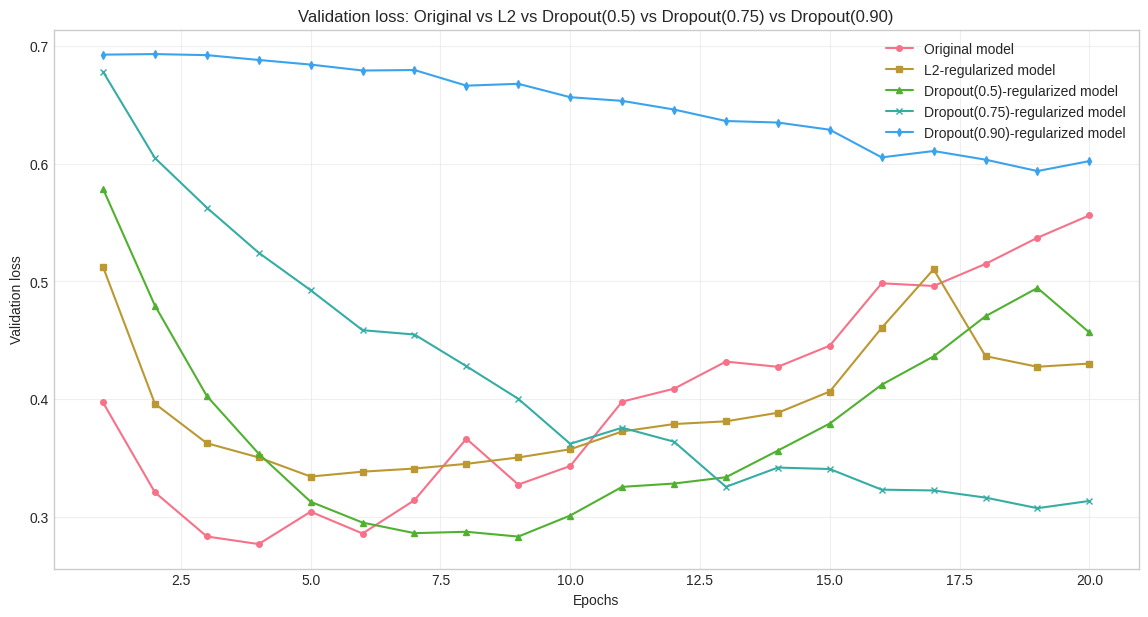

Menor pérdida de validación (Original): 0.2768 en época 4
Menor pérdida de validación (L2=0.001): 0.3342 en época 5
Menor pérdida de validación (Dropout=0.5): 0.2832 en época 9
Menor pérdida de validación (Dropout=0.75): 0.3073 en época 19
Menor pérdida de validación (Dropout=0.90): 0.5936 en época 19


In [80]:
plt.figure(figsize=(14, 7))
plt.plot(epochs, val_loss, 'o-', label='Original model', markersize=4)
plt.plot(epochs, l2_val_loss, 's-', label='L2-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss, '^-', label='Dropout(0.5)-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss_25_signal, 'x-', label='Dropout(0.75)-regularized model', markersize=4)
plt.plot(epochs, dropout_val_loss_10_signal, 'd-', label='Dropout(0.90)-regularized model', markersize=4)
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.title('Validation loss: Original vs L2 vs Dropout(0.5) vs Dropout(0.75) vs Dropout(0.90)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Menor pérdida de validación (Original): {min(val_loss):.4f} en época {np.argmin(val_loss) + 1}")
print(f"Menor pérdida de validación (L2=0.001): {min(l2_val_loss):.4f} en época {np.argmin(l2_val_loss) + 1}")
print(f"Menor pérdida de validación (Dropout=0.5): {min(dropout_val_loss):.4f} en época {np.argmin(dropout_val_loss) + 1}")
print(f"Menor pérdida de validación (Dropout=0.75): {min(dropout_val_loss_25_signal):.4f} en época {np.argmin(dropout_val_loss_25_signal) + 1}")
print(f"Menor pérdida de validación (Dropout=0.90): {min(dropout_val_loss_10_signal):.4f} en época {np.argmin(dropout_val_loss_10_signal) + 1}")

## Topico Adicional para Lectura: Validación Cruzada (Cross-Validation)

La validación cruzada es una técnica utilizada para evaluar el rendimiento de un modelo en datos no vistos, dividiendo el conjunto de datos en múltiples subconjuntos. En este caso, utilizaremos **K-Fold Cross-Validation** estratificado, que divide los datos en K "folds" (pliegues) y entrena el modelo K veces, utilizando un fold diferente como conjunto de validación en cada iteración. La estratificación asegura que la proporción de clases (positivas/negativas) se mantenga en cada fold, lo cual es importante para conjuntos de datos desequilibrados.

Esto nos proporcionará una estimación más robusta del rendimiento del modelo, reduciendo la varianza que puede ocurrir con una única división entrenamiento-validación.

In [81]:
# Install scikeras to bridge Keras with scikit-learn
!pip install scikeras

In [82]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scikeras.wrappers import KerasClassifier

# Define a function to create the Keras model (using the original architecture for simplicity)
def create_keras_model():
    model = models.Sequential()
    model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
    model.add(layers.Dense(16, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Create a KerasClassifier wrapper for scikit-learn compatibility
k_model = KerasClassifier(model=create_keras_model, epochs=4, batch_size=512, verbose=0)

# Define the cross-validation strategy
n_splits = 5 # Number of folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Perform cross-validation
print(f"Performing {n_splits}-fold cross-validation...")
cv_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(x_train, y_train)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    X_train_fold, X_val_fold = x_train[train_idx], x_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Train the model
    history_cv = k_model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold))

    # Evaluate on the validation fold (equivalent to test set for this fold)
    # KerasClassifier uses .score() for evaluation, not .evaluate()
    accuracy_cv = k_model.score(X_val_fold, y_val_fold)
    cv_scores.append(accuracy_cv)
    print(f"Fold {fold + 1} Validation Accuracy: {accuracy_cv:.4f}")

print(f"\nAverage Cross-Validation Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Performing 5-fold cross-validation...

--- Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Validation Accuracy: 0.8880

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Validation Accuracy: 0.8860

--- Fold 3/5 ---


...

Fold 3 Validation Accuracy: 0.8908

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Validation Accuracy: 0.8932

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Validation Accuracy: 0.8900

Average Cross-Validation Accuracy: 0.8896 (+/- 0.0025)


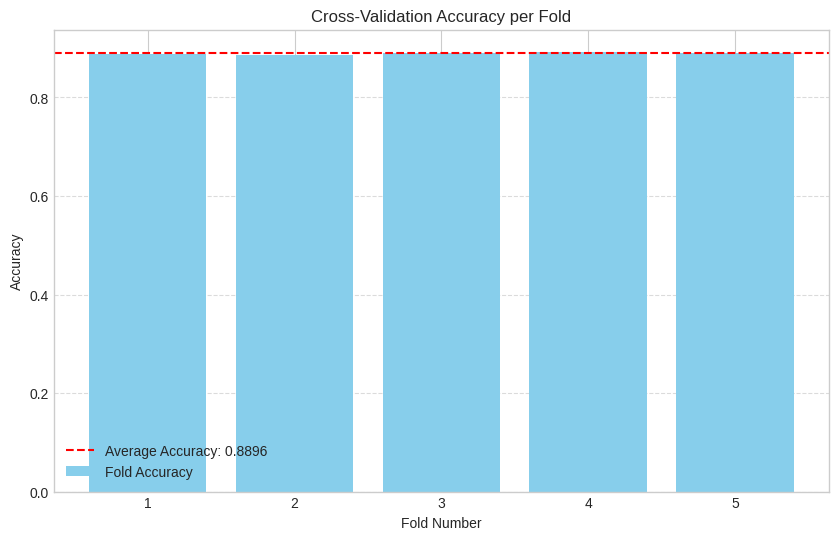

In [83]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming cv_scores is available from the previous cross-validation step

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(cv_scores) + 1), cv_scores, color='skyblue', label='Fold Accuracy')
plt.axhline(np.mean(cv_scores), color='red', linestyle='--', label=f'Average Accuracy: {np.mean(cv_scores):.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy per Fold')
plt.xticks(range(1, len(cv_scores) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()